In [49]:
# Import Libraries
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering



In [50]:
# Load scaled Data
X = pd.read_csv("data/X_train_scaled.csv")

In [51]:
# Determine optimal number of clusters using the Elbow Method
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)  # inertia

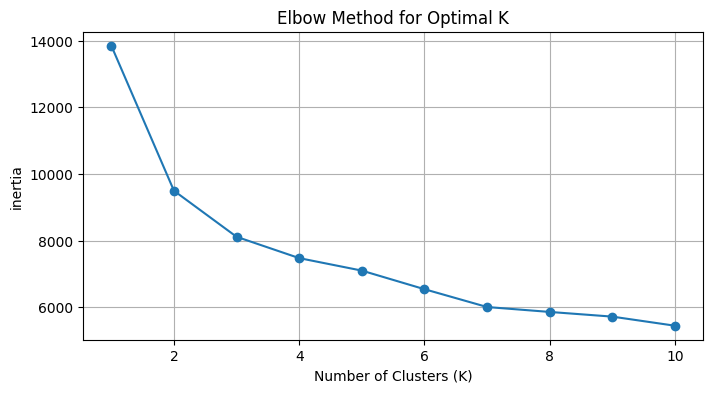

In [52]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("inertia")
plt.grid(True)
plt.show()

In [53]:
# Silhouette Score (BEST K Selection)
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

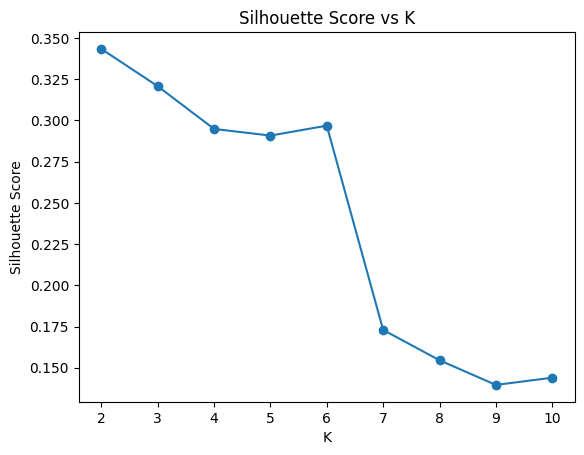

In [54]:
# Plot Silhouette Scores
plt.plot(range(2, 11), sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

## K-Means Clustering

In [55]:
# Final K-Means Model (Best K)
best_k = 2  # (from elbow + silhouette it can be decided)

kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(X)

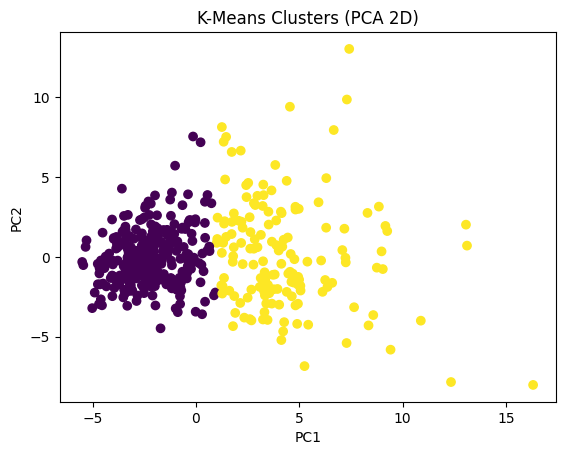

In [56]:
# PCA Visualization (2D Clusters)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("K-Means Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [57]:
# K-Means (Without PCA)

results = []
kmeans = KMeans(n_clusters=2, random_state=42)

labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)

results.append({
    'Model': 'K-Means',
    'Data': 'Scaled',
    'Silhouette Score': score
})

In [58]:
# K-Means (WITH PCA)

kmeans_pca = KMeans(n_clusters=2, random_state=42)

labels_pca = kmeans_pca.fit_predict(X_pca)

score_pca = silhouette_score(X_pca, labels_pca)

results.append({
    'Model': 'K-Means',
    'Data': 'PCA',
    'Silhouette Score': score_pca
})


## Hierarchical Clustering



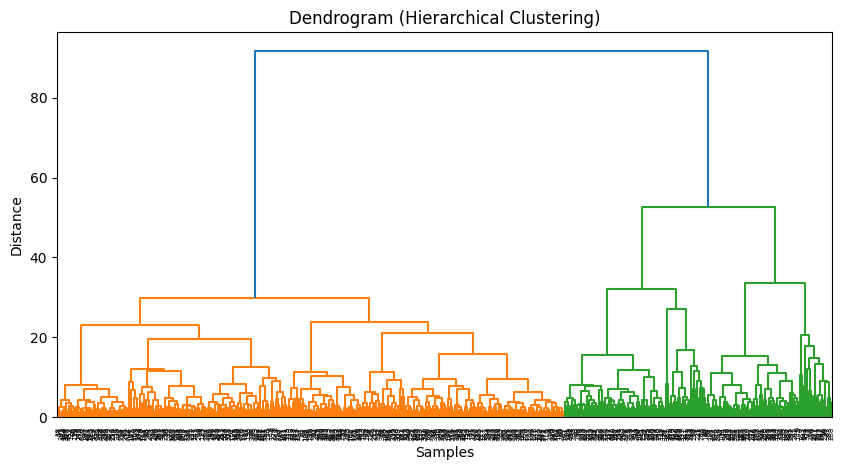

In [59]:
# Hierarchical Clustering - Dendrogram

plt.figure(figsize=(10,5))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [60]:
# Silhouette Score

scores = []

for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X)
    scores.append(silhouette_score(X, labels))

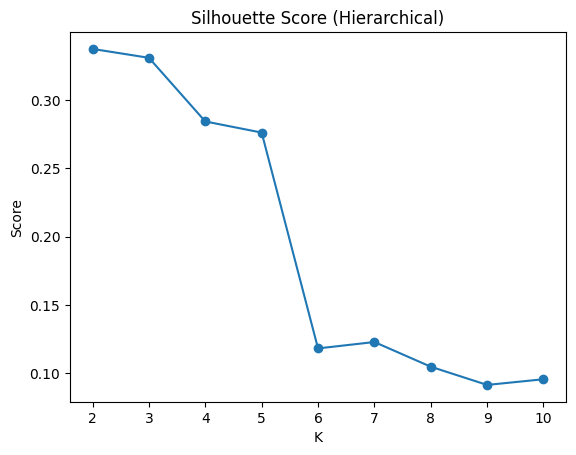

In [61]:
# Silhouette Score vs K
plt.plot(range(2, 11), scores, marker='o')
plt.title("Silhouette Score (Hierarchical)")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

In [62]:
# Hierarchical Clustering (Without PCA)

Z = linkage(X, method='ward')

labels = fcluster(Z, 2, criterion='maxclust')

score = silhouette_score(X, labels)

results.append({
    'Model': 'Hierarchical',
    'Data': 'Scaled',
    'Silhouette Score': score
})

In [63]:
# Hierarchical Clustering (WITH PCA)

Z_pca = linkage(X_pca, method='ward')

labels_pca = fcluster(Z_pca, 2, criterion='maxclust')

score_pca = silhouette_score(X_pca, labels_pca)

results.append({
    'Model': 'Hierarchical',
    'Data': 'PCA',
    'Silhouette Score': score_pca
})

In [64]:
# Results Table
results_df = pd.DataFrame(results)
print(results_df)

          Model    Data  Silhouette Score
0       K-Means  Scaled          0.343381
1       K-Means     PCA          0.506180
2  Hierarchical  Scaled          0.337418
3  Hierarchical     PCA          0.460648


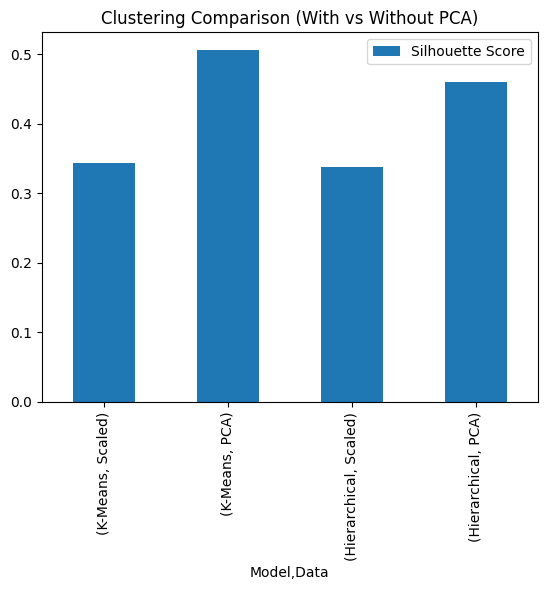

In [65]:
# Comparison (With vs Without PCA)
results_df.set_index(['Model','Data']).plot(kind='bar')
plt.title("Clustering Comparison (With vs Without PCA)")
plt.show()

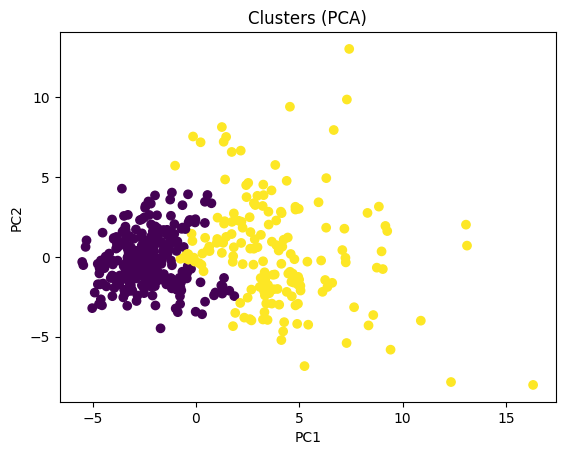

In [66]:
# PCA Cluster Visualization

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
plt.title("Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()